# Study 9: Forward Pass — P(p' | u), Per Condition

Runs the full generative model forward separately for each participant condition.
Each condition saw different training features, so the GP should be conditioned on
only that condition's training set.

| Condition | Training features | Participants |
|---|---|---|
| physical | physical category, split=train (15) | ~101 |
| diet | diet_preferences category, split=train (15) | ~101 |
| personality | personality_behaviors category, split=train (15) | ~101 |
| heterogeneous | in_heterogenous=True across all categories (15) | ~99 |

All conditions rate the same 15 test features.
Predictions are compared to each condition's participants' ratings separately.

In [ ]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"  # force CPU — Metal (jax-metal 0.1.1) is incompatible with blackjax

import sys, csv, pickle as pkl
sys.path.insert(0, ".")

import numpy as np
import jax
import jax.numpy as jnp
import blackjax
import matplotlib.pyplot as plt

from model_jax import (
    make_log_density_fn_joint,
    fit_beta_mixtures_all_features,
    beta_mixture_log_likelihood,
)

print(f"backend: {jax.default_backend()}")

In [2]:
with open('../features/set2_features_dataframe.pkl', 'rb') as f:
    df = pkl.load(f)

with open('../../data/study9.csv') as f:
    rows = list(csv.reader(f))
CSV_HEADER = rows[0]
data_rows  = rows[3:]
COND_IDX   = CSV_HEADER.index('condition')

print(f"Features: {len(df)} total, {(df.split=='train').sum()} train, {(df.split=='test').sum()} test")
print(f"Participants: {len(data_rows)}")

Features: 60 total, 45 train, 15 test
Participants: 402


In [3]:
# Test features: same 15 for all conditions
CSV_TO_FEATURE = {
    'diet_can_eat_spicy_1':  'can eat spicy food',
    'diet_breakfast_late_1': 'eat breakfast very late',
    'diet_five_meals_day_1': 'eat five meals a day',
    'diet_like_juice_pulp_1':'like juice with pulp',
    'diet_pepper_on_all_1':  'put pepper on all their foods',
    'pers_cry_easily_1':     'cry easily',
    'pers_collect_rocks_1':  'like to collect rocks',
    'pers_like_to_dance_1':  'like to dance',
    'pers_like_highfive_1':  'like to give high-fives',
    'pers_read_books_1':     'like to read books',
    'phys_can_roll_tongue_1':'can roll their tongue',
    'phys_can_snap_toes_1':  'can snap with their toes',
    'phys_can_wiggle_ears_1':'can wiggle their ears',
    'phys_cold_hands_feet_1':'have cold hands and feet',
    'phys_snore_sleep_1':    'snore when they sleep',
}
TEST_CSV_COLS      = list(CSV_TO_FEATURE.keys())
test_feature_names = list(CSV_TO_FEATURE.values())
feat_idx           = df.set_index('feature')

x_test = jnp.array(
    [feat_idx.loc[name, ['x_2d', 'y_2d']].values for name in test_feature_names]
)  # (J, 2)
J = len(test_feature_names)

# Training features per condition
COND_TRAIN = {
    'physical':      df[(df.split == 'train') & (df.category == 'physical')],
    'diet':          df[(df.split == 'train') & (df.category == 'diet_preferences')],
    'personality':   df[(df.split == 'train') & (df.category == 'personality_behaviors')],
    'heterogeneous': df[(df.split == 'train') & (df.in_heterogenous == True)],
}
for cond, cdf in COND_TRAIN.items():
    print(f"{cond:15s}: {len(cdf)} training features")

physical       : 15 training features
diet           : 15 training features
personality    : 15 training features
heterogeneous  : 15 training features


In [4]:
# Parse participant ratings split by condition
col_indices = [CSV_HEADER.index(c) for c in TEST_CSV_COLS]

responses_by_cond = {c: [] for c in COND_TRAIN}
for row in data_rows:
    cond = row[COND_IDX].strip()
    if cond not in responses_by_cond:
        continue
    try:
        vals = [int(row[i]) / 100.0 for i in col_indices]
        responses_by_cond[cond].append(vals)
    except (ValueError, IndexError):
        pass

responses_by_cond = {c: jnp.array(v) for c, v in responses_by_cond.items()}
for cond, r in responses_by_cond.items():
    print(f"{cond:15s}: {r.shape[0]} participants, mean prevalence range [{float(r.mean(0).min()):.2f}, {float(r.mean(0).max()):.2f}]")

physical       : 101 participants, mean prevalence range [0.47, 0.75]
diet           : 101 participants, mean prevalence range [0.40, 0.69]
personality    : 101 participants, mean prevalence range [0.41, 0.77]
heterogeneous  : 99 participants, mean prevalence range [0.41, 0.74]


In [5]:
params = {
    'mu_0':         0.0,
    'length_scale': 0.4,
    'output_scale': 1.5,
    'beta':         3.0,
}

In [6]:
n_warmup  = 500
n_samples = 2000

cond_results = {}  # condition → {pz1_test, test_coherences_all, pz1_samples_all}

for cond, cdf in COND_TRAIN.items():
    print(f"\n=== {cond} ===")
    x_train_c = jnp.array(cdf[['x_2d', 'y_2d']].values)       # (n_train_c, 2)
    u_train_c = jnp.zeros(len(cdf), dtype=jnp.int32)           # all generic

    log_density_fn = make_log_density_fn_joint(u_train_c, x_train_c, x_test, params)

    init_position = {
        'training_coherences': jnp.zeros(len(cdf)),
        'test_coherences':     jnp.zeros(J),
    }
    print("  log_density at init:", log_density_fn(init_position))

    rng_key = jax.random.PRNGKey(0)
    rng_key, warmup_key = jax.random.split(rng_key)
    warmup = blackjax.window_adaptation(blackjax.nuts, log_density_fn)
    (state, nuts_params), _ = warmup.run(warmup_key, init_position, num_steps=n_warmup)
    print(f"  Warmup done. Step size: {nuts_params['step_size']:.4f}")

    nuts = blackjax.nuts(log_density_fn, **nuts_params)

    @jax.jit
    def one_step(state, key):
        return nuts.step(key, state)

    keys = jax.random.split(rng_key, n_samples)
    test_coherences_all = []
    for key in keys[:-1]:
        state, _ = one_step(state, key)
        test_coherences_all.append(np.array(state.position['test_coherences']))
    test_coherences_all = np.array(test_coherences_all)  # (S, J)

    pz1_samples_all = [
        np.array(jax.nn.sigmoid(jnp.array(test_coherences_all[:, j]))) for j in range(J)
    ]
    pz1_test = np.array([float(np.mean(s)) for s in pz1_samples_all])  # (J,)

    for j, (name, pz1_j) in enumerate(zip(test_feature_names, pz1_test)):
        print(f"  [{j+1:2d}] {name:<35s}  P(z'=1) = {pz1_j:.3f}")

    cond_results[cond] = {
        'x_train':             x_train_c,
        'pz1_test':            pz1_test,
        'pz1_samples_all':     pz1_samples_all,
        'test_coherences_all': test_coherences_all,
    }


=== physical ===
  log_density at init: 53.49694
  Warmup done. Step size: 0.0070
  [ 1] can eat spicy food                   P(z'=1) = 0.609
  [ 2] eat breakfast very late              P(z'=1) = 0.622
  [ 3] eat five meals a day                 P(z'=1) = 0.606
  [ 4] like juice with pulp                 P(z'=1) = 0.619
  [ 5] put pepper on all their foods        P(z'=1) = 0.601
  [ 6] cry easily                           P(z'=1) = 0.702
  [ 7] like to collect rocks                P(z'=1) = 0.638
  [ 8] like to dance                        P(z'=1) = 0.708
  [ 9] like to give high-fives              P(z'=1) = 0.648
  [10] like to read books                   P(z'=1) = 0.646
  [11] can roll their tongue                P(z'=1) = 0.735
  [12] can snap with their toes             P(z'=1) = 0.747
  [13] can wiggle their ears                P(z'=1) = 0.758
  [14] have cold hands and feet             P(z'=1) = 0.754
  [15] snore when they sleep                P(z'=1) = 0.717

=== diet ===
  l

In [ ]:
from scipy.special import logsumexp as scipy_logsumexp
from model_jax import beta_mixture_log_likelihood

# Option 3: proper Monte Carlo integral over y' posterior, per condition
step = 10  # thin chain: 1999 → ~200 samples

for cond, res in cond_results.items():
    responses_c     = responses_by_cond[cond]   # (N_c, J)
    N_c             = responses_c.shape[0]
    test_coherences_all = res['test_coherences_all']  # (S, J)

    pred_prevalences_s = []
    log_liks_s = []

    for s in range(0, test_coherences_all.shape[0], step):
        pz1_s    = jnp.array(jax.nn.sigmoid(test_coherences_all[s]))  # (J,)
        pz1_s_bc = jnp.tile(pz1_s, (N_c, 1))                          # (N_c, J)
        beta_params_s = fit_beta_mixtures_all_features(responses_c, pz1_s_bc)

        alpha_kl_s  = np.array(beta_params_s[:, 0])
        beta_kl_s   = np.array(beta_params_s[:, 1])
        alpha_nkl_s = np.array(beta_params_s[:, 2])
        beta_nkl_s  = np.array(beta_params_s[:, 3])
        mean_kl_s   = alpha_kl_s  / (alpha_kl_s  + beta_kl_s)
        mean_nkl_s  = alpha_nkl_s / (alpha_nkl_s + beta_nkl_s)
        pred_prevalences_s.append(np.array(pz1_s) * mean_kl_s + (1 - np.array(pz1_s)) * mean_nkl_s)
        log_liks_s.append(beta_mixture_log_likelihood(responses_c, pz1_s, beta_params_s))

    S_eff           = len(pred_prevalences_s)
    pred_prevalence = np.mean(pred_prevalences_s, axis=0)         # (J,)
    log_lik         = float(scipy_logsumexp(log_liks_s) - np.log(S_eff))
    empirical_mean  = np.array(responses_c.mean(axis=0))

    res['pred_prevalence'] = pred_prevalence
    res['empirical_mean']  = empirical_mean
    res['log_lik']         = log_lik
    print(f"{cond:15s}: log_lik = {log_lik:.1f}")

In [ ]:
# Scatter: model predicted vs empirical mean per condition
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True, sharex=True)
lims = [0, 1]

test_cats = [feat_idx.loc[name, 'category'] for name in test_feature_names]
cat_colors = {
    'physical':              'tomato',
    'diet_preferences':      'steelblue',
    'personality_behaviors': 'seagreen',
}
colors = [cat_colors[c] for c in test_cats]

for ax, cond in zip(axes, COND_TRAIN):
    res = cond_results[cond]
    ax.scatter(res['empirical_mean'], res['pred_prevalence'], c=colors, zorder=3, s=50)
    for j, name in enumerate(test_feature_names):
        ax.annotate(name, (res['empirical_mean'][j], res['pred_prevalence'][j]),
                    fontsize=5, xytext=(4, 2), textcoords='offset points')
    ax.plot(lims, lims, '--', color='gray', alpha=0.4)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Empirical mean prevalence')
    ax.set_title(f"{cond}\nlog_lik={res['log_lik']:.1f}")

axes[0].set_ylabel("Model E[p'|u]")

from matplotlib.lines import Line2D
legend_elements = [Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=8, label=k)
                   for k, c in cat_colors.items()]
axes[-1].legend(handles=legend_elements, fontsize=7, loc='upper left')

plt.suptitle('Model vs. human prevalence ratings by condition (Study 9)', y=1.02)
plt.tight_layout()
plt.show()

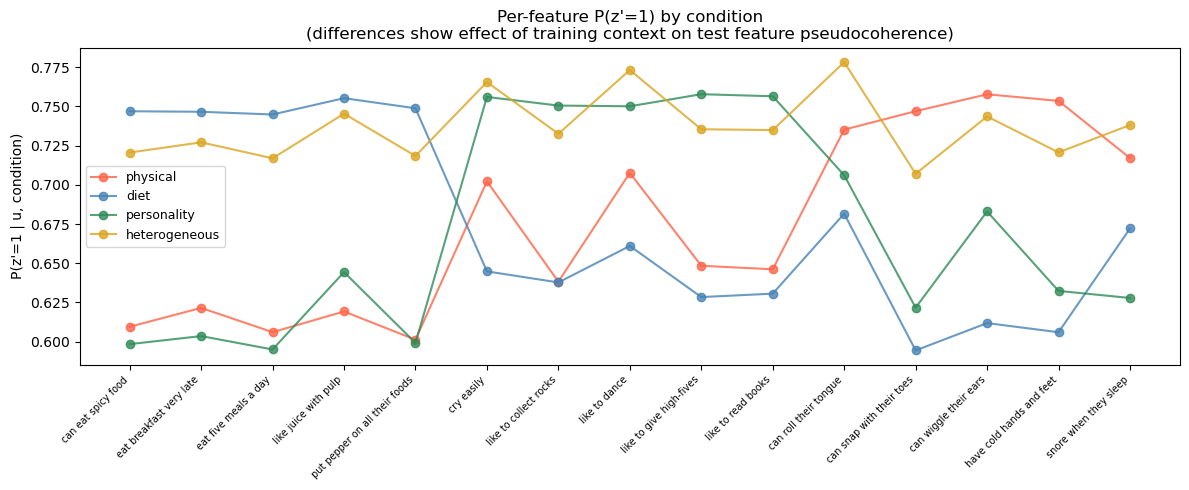

In [9]:
# P(z'=1) per feature per condition — shows how training context shifts pseudocoherence
fig, ax = plt.subplots(figsize=(12, 5))
x_pos = np.arange(J)
cond_colors = {'physical': 'tomato', 'diet': 'steelblue',
               'personality': 'seagreen', 'heterogeneous': 'goldenrod'}

for cond, res in cond_results.items():
    ax.plot(x_pos, res['pz1_test'], 'o-', alpha=0.8,
            color=cond_colors[cond], label=cond)

ax.set_xticks(x_pos)
ax.set_xticklabels(test_feature_names, rotation=45, ha='right', fontsize=7)
ax.set_ylabel("P(z'=1 | u, condition)")
ax.set_title("Per-feature P(z'=1) by condition\n(differences show effect of training context on test feature pseudocoherence)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()